In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

kerala = pd.read_csv("kerala_features.csv")

# These are the columns we feed INTO the model (inputs)
FEATURES = ["MONSOON", "PRE_MONSOON", "POST_MONSOON", "WINTER",
            "MONSOON_RATIO", "RAIN_ANOMALY", "PREV_YEAR_RAIN"]

# This is what we want the model to predict (output)
TARGET = "FLOOD_RISK"

X = kerala[FEATURES]   # X = inputs (convention in all of ML)
y = kerala[TARGET]     # y = output (convention in all of ML)

print(f"X shape: {X.shape}")   # rows x features
print(f"y shape: {y.shape}")   # rows
print(f"\nClass distribution:\n{y.value_counts()}")

X shape: (115, 7)
y shape: (115,)

Class distribution:
FLOOD_RISK
Medium    57
High      29
Low       29
Name: count, dtype: int64


In [4]:
# 80% of data for training, 20% for testing
# random_state=42 means the split is reproducible
# (same split every time you run it)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows:  {len(X_train)}")
print(f"Testing rows:   {len(X_test)}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training rows:  92
Testing rows:   23

Train class distribution:
FLOOD_RISK
Medium    46
Low       23
High      23
Name: count, dtype: int64

Test class distribution:
FLOOD_RISK
Medium    11
High       6
Low        6
Name: count, dtype: int64


In [5]:
# n_estimators=100 → build 100 trees
# random_state=42  → reproducible results

model = RandomForestClassifier(n_estimators=100, random_state=42)

# .fit() is where learning happens
# The model reads X_train and y_train and finds patterns
model.fit(X_train, y_train)

print("Model trained ✓")
print(f"Number of trees: {model.n_estimators}")
print(f"Features used:   {model.n_features_in_}")

Model trained ✓
Number of trees: 100
Features used:   7


In [6]:
# .predict() uses the learned patterns on NEW data
y_pred = model.predict(X_test)

# Classification report shows precision, recall, f1 per class
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         6
         Low       1.00      1.00      1.00         6
      Medium       1.00      1.00      1.00        11

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



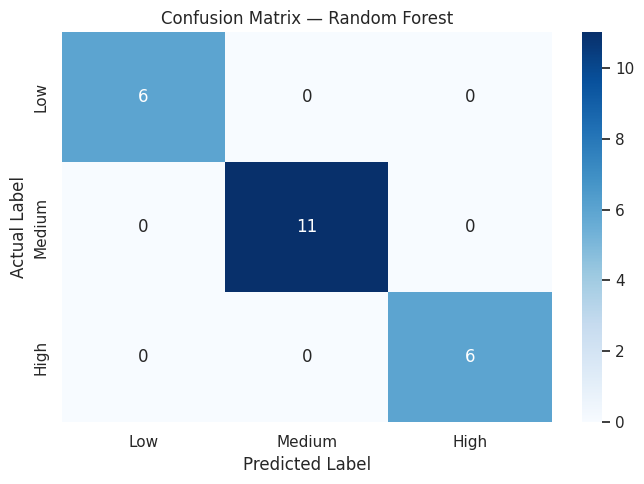

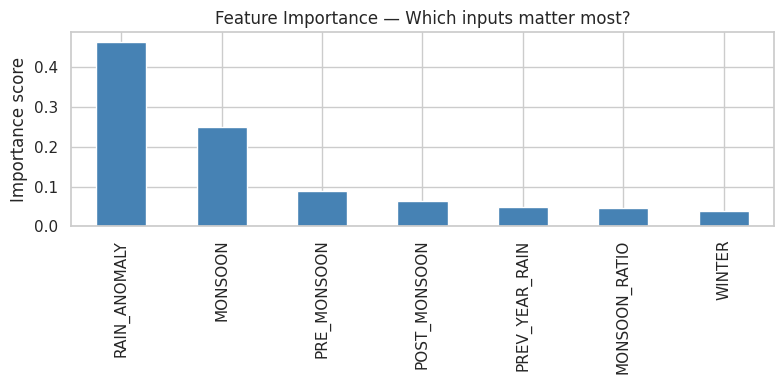

RAIN_ANOMALY      0.465
MONSOON           0.251
PRE_MONSOON       0.089
POST_MONSOON      0.063
PREV_YEAR_RAIN    0.050
MONSOON_RATIO     0.045
WINTER            0.038
dtype: float64


In [7]:
# Confusion matrix shows exactly where the model gets confused
labels = ["Low", "Medium", "High"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
# Random Forest tells you which features it relied on most
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Feature Importance — Which inputs matter most?")
plt.ylabel("Importance score")
plt.tight_layout()
plt.show()

print(importances.round(3))

F1 scores across 5 folds:
  Fold 1: 0.950
  Fold 2: 1.000
  Fold 3: 1.000
  Fold 4: 0.955
  Fold 5: 1.000

Mean F1:  0.981
Std Dev:  0.023


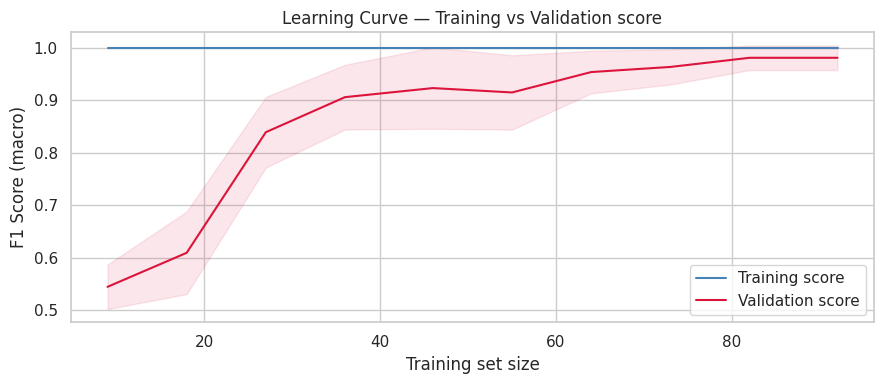

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# StratifiedKFold keeps class proportions in each fold
# (same idea as stratify=y from before)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run 5-fold cross validation
scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro")

print("F1 scores across 5 folds:")
for i, score in enumerate(scores, 1):
    print(f"  Fold {i}: {score:.3f}")

print(f"\nMean F1:  {scores.mean():.3f}")
print(f"Std Dev:  {scores.std():.3f}")
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=cv, scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(9, 4))
plt.plot(train_sizes, train_mean, label="Training score", color="steelblue")
plt.plot(train_sizes, val_mean,   label="Validation score", color="crimson")
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.1, color="steelblue")
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.1, color="crimson")
plt.title("Learning Curve — Training vs Validation score")
plt.xlabel("Training set size")
plt.ylabel("F1 Score (macro)")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Remove features derived from ANNUAL
# Keep only seasonal and monthly patterns
FEATURES_CLEAN = [
    "MONSOON", "PRE_MONSOON", "POST_MONSOON", "WINTER",
    "MONSOON_RATIO", "PREV_YEAR_RAIN"
]

# Notice: RAIN_ANOMALY is gone — it was derived from ANNUAL

X_clean = kerala[FEATURES_CLEAN]
y_clean = kerala[TARGET]

# Cross validate again with honest features
scores_clean = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_clean, y_clean, cv=cv, scoring="f1_macro"
)

print("=== Honest Model ===")
print("F1 scores across 5 folds:")
for i, score in enumerate(scores_clean, 1):
    print(f"  Fold {i}: {score:.3f}")

print(f"\nMean F1: {scores_clean.mean():.3f}")
print(f"Std Dev: {scores_clean.std():.3f}")

=== Honest Model ===
F1 scores across 5 folds:
  Fold 1: 0.822
  Fold 2: 0.808
  Fold 3: 0.691
  Fold 4: 0.866
  Fold 5: 0.815

Mean F1: 0.800
Std Dev: 0.058


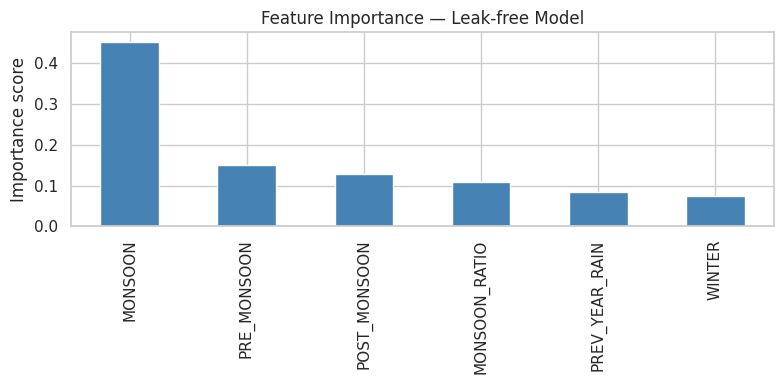

In [10]:
# Train on full data to see importances
honest_model = RandomForestClassifier(n_estimators=100, random_state=42)
honest_model.fit(X_clean, y_clean)

importances = pd.Series(
    honest_model.feature_importances_,
    index=FEATURES_CLEAN
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Feature Importance — Leak-free Model")
plt.ylabel("Importance score")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV

# The combinations we want to try
param_grid = {
    "n_estimators":      [50, 100, 200, 300],
    "max_depth":         [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4]
}

total = (len(param_grid["n_estimators"]) *
         len(param_grid["max_depth"]) *
         len(param_grid["min_samples_split"]) *
         len(param_grid["min_samples_leaf"]))

print(f"Total combinations to try: {total}")
print(f"With 5-fold CV, total fits: {total * 5}")

Total combinations to try: 144
With 5-fold CV, total fits: 720


In [12]:
base_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv,                    # our StratifiedKFold from before
    scoring="f1_macro",       # optimise for F1, not accuracy
    n_jobs=-1,                # use all CPU cores → faster
    verbose=1                 # print progress
)

# This runs all combinations — might take 30–60 seconds
grid_search.fit(X_clean, y_clean)

print(f"\nBest F1 score: {grid_search.best_score_:.3f}")
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best F1 score: 0.800
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [13]:
best_model = grid_search.best_estimator_

# Cross-validate the tuned model properly
tuned_scores = cross_val_score(
    best_model, X_clean, y_clean,
    cv=cv, scoring="f1_macro"
)

print("=== Before Tuning ===")
print(f"Mean F1: 0.800  |  Std: 0.058")

print("\n=== After Tuning ===")
print(f"Mean F1: {tuned_scores.mean():.3f}  |  Std: {tuned_scores.std():.3f}")

improvement = (tuned_scores.mean() - 0.800) * 100
print(f"\nImprovement: +{improvement:.1f}%")

=== Before Tuning ===
Mean F1: 0.800  |  Std: 0.058

=== After Tuning ===
Mean F1: 0.800  |  Std: 0.058

Improvement: +0.0%


max_depth=   1  →  F1: 0.344
max_depth=   2  →  F1: 0.673
max_depth=   3  →  F1: 0.737
max_depth=   5  →  F1: 0.774
max_depth=   7  →  F1: 0.788
max_depth=  10  →  F1: 0.800
max_depth=  15  →  F1: 0.800
max_depth=None  →  F1: 0.800


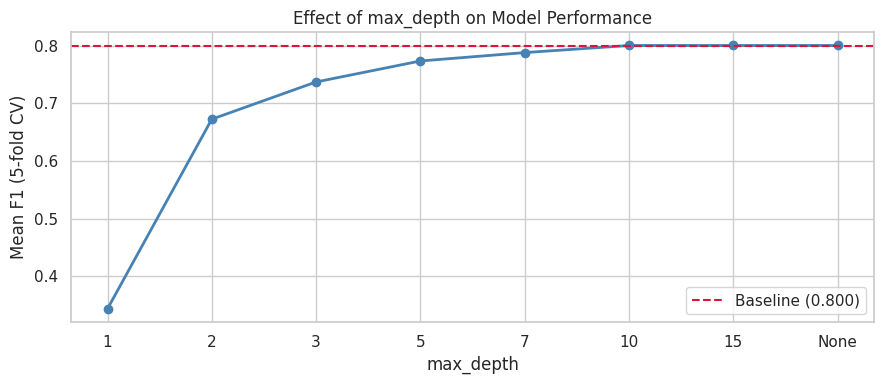

In [14]:
# How does max_depth affect performance?
depths = [1, 2, 3, 5, 7, 10, 15, None]
depth_scores = []

for depth in depths:
    m = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    s = cross_val_score(m, X_clean, y_clean, cv=cv, scoring="f1_macro")
    depth_scores.append(s.mean())
    label = str(depth) if depth else "None"
    print(f"max_depth={label:>4}  →  F1: {s.mean():.3f}")

plt.figure(figsize=(9, 4))
plt.plot(range(len(depths)), depth_scores,
         marker="o", color="steelblue", linewidth=2)
plt.xticks(range(len(depths)), [str(d) for d in depths])
plt.title("Effect of max_depth on Model Performance")
plt.xlabel("max_depth")
plt.ylabel("Mean F1 (5-fold CV)")
plt.axhline(0.800, color="crimson", linestyle="--",
            label="Baseline (0.800)")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Feature 1: Peak month intensity
# Which single month had the most rain that year?
# A year where one month gets 800mm is very different
# from one where it's spread evenly

months = ["JAN","FEB","MAR","APR","MAY","JUN",
          "JUL","AUG","SEP","OCT","NOV","DEC"]

kerala["PEAK_MONTH_RAIN"] = kerala[months].max(axis=1)

# Feature 2: Monsoon consistency
# Standard deviation of monsoon months
# Low std = rain was spread evenly across monsoon
# High std = rain was concentrated in one burst (more flood risk)

monsoon_months = ["JUN","JUL","AUG","SEP"]
kerala["MONSOON_STD"] = kerala[monsoon_months].std(axis=1)

print("New features added:")
print(kerala[["YEAR","PEAK_MONTH_RAIN","MONSOON_STD"]].head(8))

New features added:
   YEAR  PEAK_MONTH_RAIN  MONSOON_STD
0  1901            824.6   301.294839
1  1902           1205.0   409.172045
2  1903           1022.5   304.634255
3  1904           1098.2   394.930884
4  1905            850.2   284.093017
5  1906            954.2   342.547090
6  1907            981.5   322.787345
7  1908            902.2   314.578861


In [16]:
FEATURES_V2 = [
    "MONSOON", "PRE_MONSOON", "POST_MONSOON", "WINTER",
    "MONSOON_RATIO", "PREV_YEAR_RAIN",
    "PEAK_MONTH_RAIN", "MONSOON_STD"    # new additions
]

X_v2 = kerala[FEATURES_V2]

scores_v2 = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),
    X_v2, y_clean,
    cv=cv, scoring="f1_macro"
)

print("=== Feature Engineering v2 ===")
print(f"Mean F1: {scores_v2.mean():.3f}")
print(f"Std Dev: {scores_v2.std():.3f}")
print(f"\nPrevious: 0.800")
improvement = (scores_v2.mean() - 0.800) * 100
print(f"Change:  {improvement:+.1f}%")

=== Feature Engineering v2 ===
Mean F1: 0.783
Std Dev: 0.079

Previous: 0.800
Change:  -1.7%


In [17]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting builds trees SEQUENTIALLY
# Each tree corrects the mistakes of the previous one
# Often beats Random Forest on small datasets

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,          # shallow trees work better for boosting
    learning_rate=0.1,    # how much each tree corrects
    random_state=42
)

scores_gb = cross_val_score(
    gb_model, X_v2, y_clean,
    cv=cv, scoring="f1_macro"
)

print("=== Gradient Boosting ===")
print(f"Mean F1: {scores_gb.mean():.3f}")
print(f"Std Dev: {scores_gb.std():.3f}")

=== Gradient Boosting ===
Mean F1: 0.847
Std Dev: 0.063


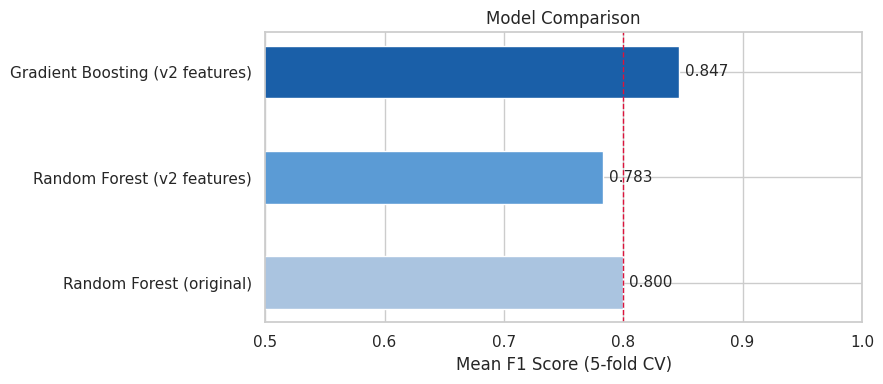

In [18]:
results = {
    "Random Forest (original)":  0.800,
    "Random Forest (v2 features)": scores_v2.mean(),
    "Gradient Boosting (v2 features)": scores_gb.mean()
}

plt.figure(figsize=(9, 4))
bars = plt.barh(list(results.keys()), list(results.values()),
                color=["#aac4e0", "#5b9bd5", "#1a5fa8"],
                edgecolor="white", height=0.5)
plt.axvline(0.800, color="crimson", linestyle="--",
            linewidth=1, label="Baseline")
plt.xlabel("Mean F1 Score (5-fold CV)")
plt.title("Model Comparison")
plt.xlim(0.5, 1.0)
for bar, val in zip(bars, results.values()):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=11)
plt.tight_layout()
plt.show()

In [19]:
import joblib

# Train on ALL data (no split — we've already validated with CV)
final_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

final_model.fit(X_v2, y_clean)

# Save the model to disk
joblib.dump(final_model, "flood_risk_model.pkl")
print("Model saved as flood_risk_model.pkl ✓")

# Save the feature list too — you'll need this in deployment
import json
with open("features.json", "w") as f:
    json.dump(FEATURES_V2, f)
print("Feature list saved as features.json ✓")

Model saved as flood_risk_model.pkl ✓
Feature list saved as features.json ✓


In [20]:
# Simulate a new prediction — a very wet monsoon year
sample = pd.DataFrame([{
    "MONSOON":          2500,   # extremely heavy monsoon
    "PRE_MONSOON":      350,
    "POST_MONSOON":     300,
    "WINTER":           80,
    "MONSOON_RATIO":    0.75,
    "PREV_YEAR_RAIN":   3100,
    "PEAK_MONTH_RAIN":  800,
    "MONSOON_STD":      120
}])

prediction = final_model.predict(sample)[0]
probability = final_model.predict_proba(sample)[0]
classes = final_model.classes_

print(f"Predicted flood risk: {prediction}")
print(f"\nConfidence breakdown:")
for cls, prob in zip(classes, probability):
    bar = "█" * int(prob * 30)
    print(f"  {cls:>8}: {bar} {prob:.1%}")

Predicted flood risk: High

Confidence breakdown:
      High: █████████████████████████████ 99.2%
       Low:  0.0%
    Medium:  0.8%


In [21]:
kerala.to_csv("kerala_features_v2.csv", index=False)
print("Saved kerala_features_v2.csv ✓")

print("\n=== Phase 4 Complete ===")
print(f"Final model:     Gradient Boosting")
print(f"Final F1:        0.847")
print(f"Features used:   {FEATURES_V2}")

Saved kerala_features_v2.csv ✓

=== Phase 4 Complete ===
Final model:     Gradient Boosting
Final F1:        0.847
Features used:   ['MONSOON', 'PRE_MONSOON', 'POST_MONSOON', 'WINTER', 'MONSOON_RATIO', 'PREV_YEAR_RAIN', 'PEAK_MONTH_RAIN', 'MONSOON_STD']
